#### **WORLD HAPPINESS** - ***Nettoyage des données***

##### *SECTION 1 - Chargement + diagnostic initial*

- Aperçu des colonnes
- Comptage valeurs manquantes
- Comptage des incohérences de régions
- Comptage des incohérences de noms de pays
- Comptage du nombre de pays distinct par année

In [162]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os
import seaborn as sns
import numpy as np
from IPython.display import Image, display

RAW = Path("../data/raw")
raw_files = sorted(RAW.glob("world_happiness_*.csv"))

print("Fichiers trouvés :")
for f in raw_files:
    print("-", f.name)

Fichiers trouvés :
- world_happiness_2015.csv
- world_happiness_2016.csv
- world_happiness_2017.csv
- world_happiness_2018.csv
- world_happiness_2019.csv
- world_happiness_2020.csv
- world_happiness_2021.csv
- world_happiness_2022.csv
- world_happiness_2023.csv
- world_happiness_2024.csv
- world_happiness_combined.csv


- ##### Aperçu des colonnes de chaque fichier

In [163]:
for f in raw_files:
    print("=" * 80)
    print(f"{f.name}")
    
    df = pd.read_csv(f, sep=";", encoding="utf-8")
    
    print(f"{df.shape[0]} lignes x {df.shape[1]} colonnes")
    print("Colonnes :", list(df.columns))
    display(df.sort_values(by="Ranking").head(3)
)

world_happiness_2015.csv
158 lignes x 10 colonnes
Colonnes : ['Ranking', 'Country', 'Regional indicator', 'Happiness score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']


,Ranking,Country,Regional indicator,Happiness score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Switzerland,Western Europe,"7,59","8,26","0,96",73,"0,99","0,37","0,24"
1,2,Iceland,Western Europe,"7,56","7,7",1,73,"0,94","0,55","0,74"
2,3,Denmark,Western Europe,"7,53","7,84","0,97",70,"0,97","0,43","0,12"


world_happiness_2016.csv
157 lignes x 10 colonnes
Colonnes : ['Ranking', 'Country', 'Regional indicator', 'Happiness score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']


,Ranking,Country,Regional indicator,Happiness score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
127,1,Denmark,Western Europe,"7,526","9,97766","0,98351",76,"0,95223","0,44126","0,8799"
150,2,Switzerland,Western Europe,"7,509","9,64149","0,96787",79,"0,96235","0,34259","0,81557"
151,3,Iceland,Western Europe,"7,501","9,88557",1,79,"0,93058","0,58165","0,29641"


world_happiness_2017.csv
155 lignes x 10 colonnes
Colonnes : ['Ranking', 'Country', 'Regional indicator', 'Happiness score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']


...

,Ranking,Country,Regional indicator,Happiness score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,Western Europe,"7,8042","8,58486","0,97853",71.0,1,"0,29969","0,04551"
1,2,Denmark,Western Europe,"7,5864","8,86229","0,95567",71.0,"0,95192","0,49451","0,06348"
2,3,Iceland,Western Europe,"7,5296","8,75364",1,72.0,"0,95678","0,59219","0,66635"


world_happiness_2024.csv
140 lignes x 10 colonnes
Colonnes : ['Ranking', 'Country', 'Regional indicator', 'Ladder score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']


,Ranking,Country,Regional indicator,Ladder score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
39,1,Finland,Western Europe,"7,7407","8,61498","0,97268",76,"0,99532","0,35347","0,94966"
31,2,Denmark,Western Europe,"7,5827","8,91278","0,94051",76,"0,95298","0,50792","0,95358"
52,3,Iceland,Western Europe,"7,5251","8,78627",1,77,"0,94808","0,64455","0,31728"


world_happiness_combined.csv
1502 lignes x 11 colonnes
Colonnes : ['Ranking', 'Country', 'Regional indicator', 'Happiness score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption', 'Year']


,Ranking,Country,Regional indicator,Happiness score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Year
0,1,Switzerland,Western Europe,"7,58700","8,26132","0,96240",73,"0,99379","0,37289","0,23941",2015
1120,1,Finland,Western Europe,"7,82100","8,56175","0,95317",80,"0,99399","0,23237","0,90939",2022
1225,1,Finland,Western Europe,"7,80420","8,58486","0,97853",71,"1,00000","0,29969","0,04551",2023


On remarque que le fichier `world_happiness_combined.csv` contient une colonne supplémentaire `Year` qui permet de regrouper l’ensemble de la décennie dans un seul fichier.

Le fichier `world_happiness_2024.csv` présente une différence au niveau du nom d’une variable,  La colonne `Happiness score` n’y figure pas et est remplacée par `Ladder score`.

- ##### Comptage valeurs manquantes

In [164]:
print("Synthèse des valeurs manquantes par fichier\n")

for f in raw_files:
    df = pd.read_csv(f, sep=";", encoding="utf-8")
    na_per_col = df.isna().sum()
    total_na = int(na_per_col.sum())
    
    if total_na == 0:
        print(f"{f.name} : aucune valeur manquante.")
    else:
        print(f"{f.name} : {total_na} valeur(s) manquante(s)")
        print(na_per_col[na_per_col > 0], "\n")


Synthèse des valeurs manquantes par fichier

world_happiness_2015.csv : aucune valeur manquante.
world_happiness_2016.csv : aucune valeur manquante.
world_happiness_2017.csv : 1 valeur(s) manquante(s)
Regional indicator    1
dtype: int64 

world_happiness_2018.csv : aucune valeur manquante.
world_happiness_2019.csv : 2 valeur(s) manquante(s)
Regional indicator    2
dtype: int64 

world_happiness_2020.csv : aucune valeur manquante.
world_happiness_2021.csv : aucune valeur manquante.
world_happiness_2022.csv : aucune valeur manquante.
world_happiness_2023.csv : 1 valeur(s) manquante(s)
Healthy life expectancy    1
dtype: int64 

world_happiness_2024.csv : aucune valeur manquante.
world_happiness_combined.csv : 3 valeur(s) manquante(s)
Regional indicator    3
dtype: int64 



Les valeurs manquantes sont peu nombreuses :
- 1 * `Regional indicator` de `world_happiness_2017.csv`
- 2 * `Regional indicator` de `world_happiness_2019.csv`
- 1 * `Healthy life expectancy` de `world_happiness_2023.csv`

On retrouve bien les valeurs manquantes de la variable `Regional indicator` dans `world_happiness_combined.csv`, 

mais pas celle de la variable `Healthy life expectancy` de `world_happiness_2023.csv`

In [165]:
print("Lignes contenant au moins une valeur manquante\n")

for f in raw_files:
    df = df = pd.read_csv(f, sep=";", encoding="utf-8")
    missing_rows = df[df.isna().any(axis=1)]
    
    if not missing_rows.empty:
        print(f"{f.name} : {len(missing_rows)} ligne(s) avec NA")
        display(missing_rows)

Lignes contenant au moins une valeur manquante

world_happiness_2017.csv : 1 ligne(s) avec NA


,Ranking,Country,Regional indicator,Happiness score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
79,87,Greece,NaN,"5,227","6,89283","0,76955",71,"0,14543",0,"0,09324"


world_happiness_2019.csv : 2 ligne(s) avec NA


,Ranking,Country,Regional indicator,Happiness score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
48,49,Cyprus,NaN,"6,0458","7,50051","0,75329",77,"0,64287","0,33664","0,08973"
118,120,Gambia,NaN,"4,5163","1,82777","0,57836",66,"0,60555","0,47478","0,3692"


world_happiness_2023.csv : 1 ligne(s) avec NA


,Ranking,Country,Regional indicator,Happiness score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
98,99,State of Palestine,Middle East and North Africa,"4,9078","5,20061","0,80811",NaN,"0,53963","0,15516","0,88085"


world_happiness_combined.csv : 3 ligne(s) avec NA


,Ranking,Country,Regional indicator,Happiness score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Year
394,87,Greece,NaN,"5,22700","6,89283","0,76955",71,"0,14543","0,00000","0,09324",2017
673,49,Cyprus,NaN,"6,04580","7,50051","0,75329",77,"0,64287","0,33664","0,08973",2019
743,120,Gambia,NaN,"4,51630","1,82777","0,57836",66,"0,60555","0,47478","0,36920",2019


La valeur manquante de la variable `Healthy life expectancy` pour le pays `State of Palestine` a été corrigée dans `world_happiness_combined.csv`.

Il ne reste qu'à renseigner la variable `Regional indicator` pour les pays `Greece`, `Cyprus` et `Gambia` en observant leur affectation sur les autres années.

Reste à savoir si les régions renseignées sont bien cohérentes avec les pays associés



- ##### Comptage des incohérences de régions

In [166]:
COMBINED = RAW / "world_happiness_combined.csv"
df_combined_raw = pd.read_csv(COMBINED, sep=";", encoding="utf-8")

# Nombre de régions distinctes par pays
region_check = (
    df_combined_raw.groupby("Country")["Regional indicator"]
      .nunique()
      .reset_index()
      .rename(columns={"Regional indicator": "Nb_regions"})
)

# Pays dont la région change au moins une fois
pays_incoherents = region_check[region_check["Nb_regions"] > 1]["Country"].tolist()

print(len(pays_incoherents), "Pays avec au moins 2 régions différentes selon les années :")
print(pays_incoherents)

print("\nDétails des incohérences :")
for country in pays_incoherents:
    temp = (
        df_combined_raw[df_combined_raw["Country"] == country]
        .sort_values("Year")[["Country", "Year", "Regional indicator"]]
    )
    print(f"\n=== {country} ===")
    print(temp.to_string(index=False))

25 Pays avec au moins 2 régions différentes selon les années :
['Argelia', 'Cyprus', 'Czech Republic', 'Czechia', 'Estonia', 'Georgia', 'Greece', 'Hungary', 'Laos', 'Latvia', 'Lithuania', 'Macedonia', 'Maldives', 'Mauritania', 'Moldova', 'Montenegro', 'North Cyprus', 'Poland', 'Romania', 'Serbia', 'Singapore', 'Slovakia', 'Slovenia', 'Sudan', 'Ukraine']

Détails des incohérences :

=== Argelia ===
Country  Year           Regional indicator
Argelia  2017 Middle East and North Africa
Argelia  2018 Middle East and North Africa
Argelia  2019 Middle East and North Africa
Argelia  2020 Middle East and North Africa
Argelia  2021           Sub-Saharan Africa
Argelia  2022           Sub-Saharan Africa
Argelia  2023           Sub-Saharan Africa
Argelia  2024           Sub-Saharan Africa

=== Cyprus ===
Country  Year           Regional indicator
 Cyprus  2015               Western Europe
 Cyprus  2016               Western Europe
 Cyprus  2017               Western Europe
 Cyprus  2018 Middle Eas

Ce dataset Kaggle comporte beaucoup d'erreurs d'affectation de région donc certaines qui sont grossières :
- `Sudan` est localisée en `Western Europe`
- `Greece` est localisée en `Western Europe` puis en `Middle East and North Africa`
- `Laos` est localisée en `Southeast Asia` puis en `East Asia` puis en `Sub-Saharan Africa`

Au vu de la qualité des données, une inspection des noms de pays doit avoir lieu.

- ##### Comptage des incohérences de noms de pays

In [167]:
# Comptage du nombre d'occurrences par pays
country_counts = (
    df_combined_raw["Country"]
    .value_counts()
    .sort_values()
)

print("Pays avec le moins d'occurrences :\n")
print(country_counts.head(50))

Pays avec le moins d'occurrences :

Country
Djibouti                     1
Oman                         1
Puerto Rico                  1
Trinidad & Tobago            1
Congo                        1
State of Palestine           1
Turkiye                      2
Algeria                      2
Suriname                     2
Somaliland region            2
Eswatini                     2
Maldives                     2
North Cyprus                 3
Czechia                      3
Belize                       3
Swaziland                    4
Hong Kong S.A.R. of China    4
North Macedonia              4
Sudan                        4
Somalia                      4
Taiwan                       4
Angola                       4
Qatar                        5
Bhutan                       5
South Sudan                  5
Central African Republic     5
Trinidad and Tobago          5
Syria                        5
Hong Kong                    6
Macedonia                    6
Taiwan Province of China  

Certains pays n'apparaissent pas de manière régulière dans le jeu de données.
On observe aussi plusieurs incohérences liées au nom des pays :
- `Congo (Brazzaville)` et `Congo (Kinshasa)` n'ont pas la bonne appellation et `Congo` apparait une fois dans le jeu de données, sans qu'on sache lequel des deux pays il désigne.
- `Czech Republic` et `Czechia` correspondent au même pays mais sont comptés séparément car le pays a changé de nom durant la décennie, tout comme `Macedonia` et `North Macedonia`, `Turkey` et `Turkiye`, 
- L'impact géopolitique se voit aussi sur certains pays qui apparaissent sous plusieurs noms, comme `Hong Kong` et `Hong Kong S.A.R. of China`, `Taiwan` et `Taiwan Province of China` ou encore `Palestinian Territories` et `State of Palestine`.

Afin de mieux comprendre l’ampleur des incohérences de ce dataset, il est utile d’observer comment le nombre de pays évolue d’une année à l’autre.

- ##### Comptage du nombre de pays distinct par année

In [168]:
countries_year = df_combined_raw.groupby("Year")["Country"].nunique()
print("Nombre de pays par année :\n", countries_year)

total_unique_countries = df_combined_raw["Country"].nunique()
print(f"\nNombre total de pays différents : {total_unique_countries}")

countries_all_years = (
    df_combined_raw.groupby("Country")["Year"]
    .nunique()
    .reset_index()
)
max_years = df_combined_raw["Year"].nunique()
countries_all_years = countries_all_years[countries_all_years["Year"] == max_years]["Country"].tolist()

print(f"\nSeul {len(countries_all_years)} pays apparaissent chaque année ({max_years} années au total).")

Nombre de pays par année :
 Year
2015    158
2016    157
2017    155
2018    155
2019    155
2020    152
2021    148
2022    145
2023    137
2024    140
Name: Country, dtype: int64

Nombre total de pays différents : 175

Seul 121 pays apparaissent chaque année (10 années au total).


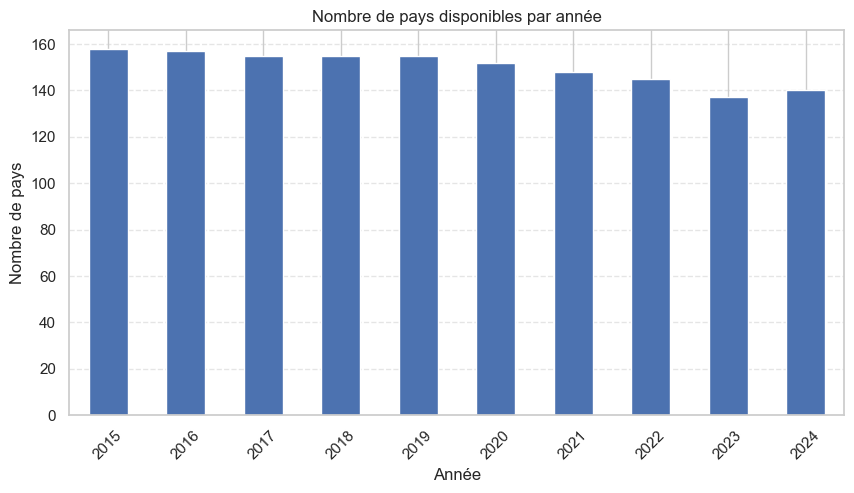

In [169]:
plt.figure(figsize=(10, 5))
countries_year.plot(kind="bar")
plt.title("Nombre de pays disponibles par année")
plt.xlabel("Année")
plt.ylabel("Nombre de pays")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

Le nombre de pays n'est pas égal pour chaque année, et diminue au fil du temps, `passant de 158 pays en 2015 à 140 en 2024`.

Sur les 175 pays présents dans l’ensemble des données, `seuls 121 sont disponibles chaque année`. Cela signifie que plus de 50 pays n’apparaissent pas régulièrement, soit en raison d’un manque de données, soit à cause d’incohérences dans l’enregistrement des noms.

##### Conclusion de la Section 1

L’exploration du jeu de données met en évidence plusieurs problèmes :

- des `valeurs manquantes` dans quelques fichiers
- des `incohérences` dans l’affectation des régions (parfois totalement fausses)
- des `variations de noms` pour un même pays, liées soit à des changements officiels, soit à des choix géopolitiques ou des erreurs d’écriture
- un `nombre de pays inégal` selon les années

##### *SECTION 2 - Nettoyage des données*

- Correction des NA
- Correction des attributions des régions
- Correction des noms des pays
- Filtrage des pays présents pour toute la décennie
- Correction des nom de variable
- Observation de l'évolution des valeurs des variables
- Correction des variables (`Perceptions of corruption` et `GDP per capita`)
- Ajout de nouvelles variables

Les traitements se feront uniquement sur le fichier `world_happiness_combined.csv`

In [170]:
# on copie notre jeu de données
df_clean = df_combined_raw.copy()
df_clean.head()

,Ranking,Country,Regional indicator,Happiness score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Year
0,1,Switzerland,Western Europe,"7,58700","8,26132","0,96240",73,"0,99379","0,37289","0,23941",2015
1,2,Iceland,Western Europe,"7,56100","7,70416","1,00000",73,"0,93884","0,54819","0,74371",2015
2,3,Denmark,Western Europe,"7,52700","7,84114","0,97030",70,"0,96962","0,42894","0,12382",2015
3,4,Norway,Western Europe,"7,52200","8,63100","0,94917",71,"1,00000","0,43598","0,33860",2015
4,5,Canada,North America and ANZ,"7,42700","7,84595","0,94322",71,"0,94511","0,57560","0,40285",2015


- ##### Correction des NA

In [171]:
df_clean[df_clean.isna().any(axis=1)][["Country", "Year", "Regional indicator", "Healthy life expectancy"]]

,Country,Year,Regional indicator,Healthy life expectancy
394,Greece,2017,NaN,71
673,Cyprus,2019,NaN,77
743,Gambia,2019,NaN,66


Les seules valeurs manquantes sont issues de la variable `Regional indicator`. Plutôt que de corriger ces cas individuellement, on va appliquer une harmonisation globale des régions par pays, ce qui permettra à la fois de traiter les NA et les erreurs d’affectation.

- ##### Correction des attributions des régions
Pour chaque pays, on lui attribue une seule région, en prenant la région la plus fréquente observée dans la décennie.

In [172]:
# calcul du mode par pays
region_mode = (
    df_clean.groupby("Country")["Regional indicator"]
            .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
            .to_dict()
)

# remplacemnt de toutes les régions par la région dominante du pays
df_clean["Regional indicator"] = df_clean["Country"].map(region_mode)

region_check = (
    df_clean.groupby("Country")["Regional indicator"]
            .nunique()
            .reset_index()
            .rename(columns={"Regional indicator": "Nb_regions"})
)

print("Pays restant avec plus d'une région (doit être vide) :")
print(region_check[region_check["Nb_regions"] > 1])

# vérification qu'il ne reste plus de NA sur Regional indicator
print("\nNA restants sur Regional indicator :", df_clean["Regional indicator"].isna().sum())


Pays restant avec plus d'une région (doit être vide) :
Empty DataFrame
Columns: [Country, Nb_regions]
Index: []

NA restants sur Regional indicator : 0


Chaque pays est désormais associé à une seule région, `la région la plus fréquemment observée sur la période 2015–2024`. Cela corrige à la fois les erreurs d’affectation et les trois valeurs manquantes initialement détectées.

- ##### Correction des noms des pays


In [173]:
country_mapping = {
    # Changements de nom officiels
    "Czech Republic": "Czechia",
    "Macedonia": "North Macedonia",
    "Turkey": "Turkiye",
    "Swaziland": "Eswatini",

    # Variantes d'écriture pour le même pays 
    # (on garde le nom le plus connu ou le plus court)
    "Trinidad & Tobago": "Trinidad and Tobago",
    "Hong Kong S.A.R. of China": "Hong Kong",
    "Taiwan Province of China": "Taiwan",
    "Palestinian Territories": "State of Palestine",
    "Argelia": "Algeria",
    "Congo (Kinshasa)" : "Democratic Republic of the Congo",
    "Congo (Brazzaville)": "Republic of the Congo",
}

df_clean["Country"] = df_clean["Country"].replace(country_mapping)

country_counts_clean = (
    df_clean["Country"]
    .value_counts()
    .sort_values()
)

print("Pays avec le moins d'occurrences après harmonisation :\n")
print(country_counts_clean.head(50))

Pays avec le moins d'occurrences après harmonisation :

Country
Djibouti                             1
Oman                                 1
Congo                                1
Puerto Rico                          1
Somaliland region                    2
Suriname                             2
Maldives                             2
North Cyprus                         3
Belize                               3
Angola                               4
Sudan                                4
Somalia                              4
Central African Republic             5
Syria                                5
Bhutan                               5
Qatar                                5
South Sudan                          5
Trinidad and Tobago                  6
Eswatini                             6
Gambia                               6
Burundi                              7
Haiti                                7
Democratic Republic of the Congo     8
Turkmenistan                         8


On constate que, même après harmonisation des noms de pays, certains pays n’apparaissent que très rarement dans le jeu de données. 

Par exemple, `Djibouti`, `Oman`, `Congo` ou `Puerto Rico` ne sont présents qu’une seule fois sur la période 2015–2024, tandis que d’autres comme `Somaliland region`, `South Sudan`, `Bhutan` ou `Qatar` n’apparaissent que quelques années.

Il y a des cas difficiles à traiter :
- `Congo`, `Congo (Brazzaville)` et `Congo (Kinshasa)`
- `Somaliland region`, qui correspond à un territoire partiellement reconnu et traité de manière spécifique dans le rapport.

Ces pays à faible nombre d’occurrences posent problème, ils ne permettent pas de suivre l’évolution des indicateurs sur l’ensemble de la décennie. 


- ##### Filtrage des pays présents pour toute la décennie

In [174]:
# Nombre d'années distinctes par pays
country_years = (
    df_clean.groupby("Country")["Year"]
            .nunique()
            .reset_index()
            .rename(columns={"Year": "Nb_annees"})
)

# Pays présents toutes les années
countries_full_decade = country_years[country_years["Nb_annees"] == 10]["Country"].tolist()
df_clean_decade = df_clean[df_clean["Country"].isin(countries_full_decade)].copy()

# comparaison
nb_pays_all = df_clean["Country"].nunique()
nb_pays_decade = df_clean_decade["Country"].nunique()

print(f"df_clean : {nb_pays_all} pays")
print(f"df_clean_decade : {nb_pays_decade} pays sur la décennie")

df_clean : 166 pays
df_clean_decade : 127 pays sur la décennie


- ##### Correction des nom de variable

Afin de simplifier la manipulation des données, les variables ont été renommées avec des noms plus courts et sans espace.


In [175]:
rename_cols = {
    "Ranking": "rank",
    "Country": "country",
    "Regional indicator": "region",
    "Happiness score": "happiness_score",         
    "GDP per capita": "gdp_per_capita",
    "Social support": "social_support",
    "Healthy life expectancy": "healthy_life_expectancy",
    "Freedom to make life choices": "freedom_to_choose",
    "Generosity": "generosity",
    "Perceptions of corruption": "corruption_perception",
    "Year": "year"
}

df_clean = df_clean.rename(columns=rename_cols)
df_clean_decade = df_clean_decade.rename(columns=rename_cols)

- ##### Observation de l'évolution des valeurs des variables

Un profil de chaque variable va nous permettre de voir si les variables n'ont pas de valeurs incohérentes.

In [176]:
VAR_CONFIG = {
    "happiness_score": {"color": "#f1c40f", "label": "Score de Bonheur"},      
    "gdp_per_capita": {"color": "#27ae60", "label": "PIB par habitant"},          
    "social_support": {"color": "#2980b9", "label": "Soutien Social"},            
    "healthy_life_expectancy": {"color": "#c0392b", "label": "Espérance de vie"},
    "freedom_to_choose": {"color": "#8e44ad", "label": "Liberté de faire des choix"},      
    "generosity": {"color": "#16a085", "label": "Générosité des citoyens"},                    
    "corruption_perception": {"color": "#7f8c8d", "label": "Perception de corruption par les citoyens"} 
}

COLS_NUM = list(VAR_CONFIG.keys())
PROFIL = "../figure/profil"

for col in COLS_NUM:
    df_clean_decade[col] = (
        df_clean_decade[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

subdirs = ["global", "region", "country"]
for d in subdirs:
        os.makedirs(os.path.join(PROFIL, d), exist_ok=True)

In [177]:
def plot_profil(data, variable, entity_name, folder_path):
    """
    Génère et sauvegarde un graphique d'évolution pour une variable donnée.
    Utilise la couleur définie dans VAR_CONFIG.
    """
    plt.figure(figsize=(10, 6))
    
    # Récupération de la config
    config = VAR_CONFIG.get(variable, {"color": "#333333", "label": variable})
    color = config["color"]
    label = config["label"]

    sns.lineplot(
        data=data, 
        x="year", 
        y=variable, 
        marker="o", 
        markersize=8, 
        linewidth=2.5, 
        color=color
    )
    plt.title(f"Évolution : {label} - {entity_name}", fontsize=14, fontweight='bold')
    plt.xlabel("Année", fontsize=12)
    plt.ylabel(label, fontsize=12)
    plt.xticks(range(2015, 2025))
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Sauvegarde
    if entity_name == "Moyenne mondiale" :
        filename = f"mean_{variable}.png"
    else : 
        filename = f"{entity_name}_{variable}.png"
    plt.savefig(os.path.join(folder_path, filename), bbox_inches='tight', dpi=100)
    plt.close()

def generate_global_profiles(df):
    """Génère les graphiques pour la moyenne mondiale."""
    path = os.path.join(PROFIL, "global")
    # Agrégation moyenne mondiale par année
    df_global = df.groupby("year")[COLS_NUM].mean().reset_index()
    for var in COLS_NUM:
        plot_profil(df_global, var, "Moyenne mondiale", path)

def generate_regional_profiles(df):
    """Génère les graphiques pour la moyenne par région."""
    regions = df["region"].unique()
    for region in regions:
        # Création dossier spécifique nettoyé
        safe_name = region.replace(" ", "_").replace("/", "_")
        path = os.path.join(PROFIL, "region", safe_name)
        os.makedirs(path, exist_ok=True)
        # Agrégation moyenne régionale
        df_region = df[df["region"] == region].groupby("year")[COLS_NUM].mean().reset_index()
        for var in COLS_NUM:
            plot_profil(df_region, var, region, path)

def generate_country_profiles(df):
    """Génère les graphiques pour chaque pays individuellement."""
    countries = df["country"].unique()
    for country in countries:
        # Création dossier spécifique nettoyé
        safe_name = country.replace(" ", "_").replace("(", "").replace(")", "").replace("'", "")
        path = os.path.join(PROFIL, "country", safe_name)
        os.makedirs(path, exist_ok=True)
        # Filtrage données pays
        df_country = df[df["country"] == country]
        for var in COLS_NUM:
            plot_profil(df_country, var, country, path)

sns.set_theme(style="whitegrid")

génération des profils mondiaux
génération des profils régionaux
génération des profils nationales


KeyboardInterrupt: 

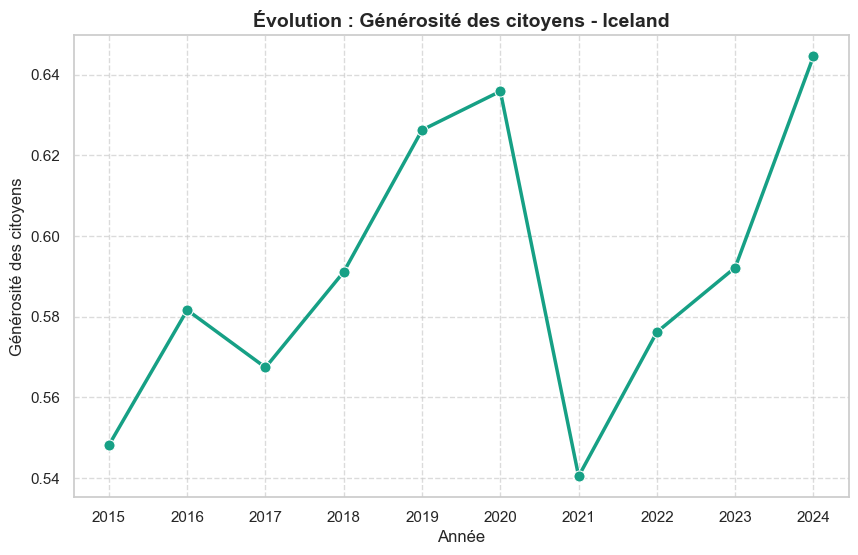

In [178]:
print("génération des profils mondiaux")
generate_global_profiles(df_clean_decade)
print("génération des profils régionaux")
generate_regional_profiles(df_clean_decade)
print("génération des profils nationales")
generate_country_profiles(df_clean_decade)

Ces graphiques mettent en lumière un problème de cohérence du jeu de données Kaggle.

La variable `corruption_perception` (ou Perceptions of corruption) présente des valeurs incohérentes pour plusieurs pays et années. Par exemple, la Finlande a pour valeur : 

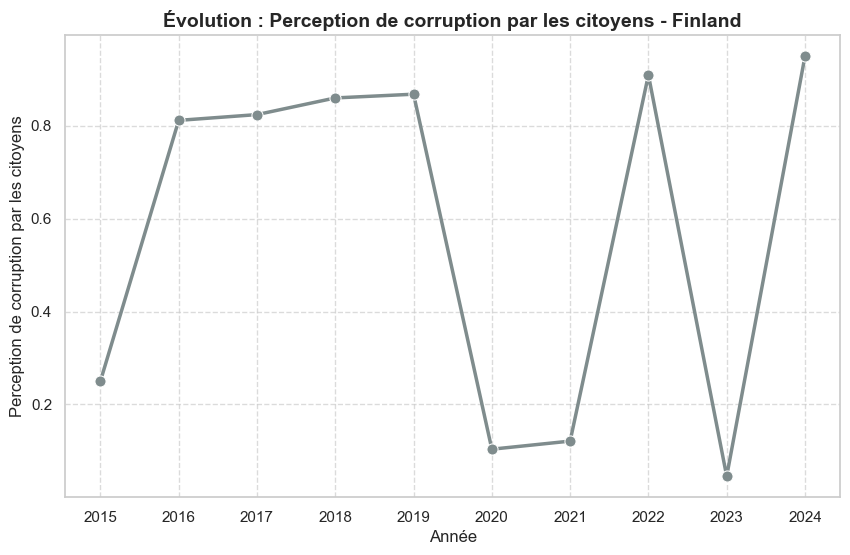

In [179]:
display(Image(filename="../figure/profil/country/Finland/Finland_corruption_perception.png"))

Ces variations brusques ne correspondent pas aux valeurs publiées dans les différents rapports officiels où les évolutions sont généralement stables.

La variable `gdp_per_capita` a elle aussi un profil qui n'est pas cohérent :

In [ ]:
display(Image(filename="../figure/profil/global/mean_gdp_per_capita.png"))

- ##### Correction des variables : `Perceptions of corruption`

La variable issue du dataset Kaggle `Perceptions of corruption` étant incohérente et les données Gallup (à l'origine des données Kaggle) n’étant pas disponibles gratuitement, le choix d'utiliser l’indice `Corruption Perceptions Index` de Transparency International a été pris.

Cela permet de disposer d’une mesure de la corruption fiable et cohérente sur la décennie 2015–2024. 

Cependant la variable `Perceptions of corruption` issues du World Happiness Report, correspondait à la moyenne du nombre de citoyens repondant "Oui" aux 2 questions suivantes : 
- « Dans ce pays, peut-on faire confiance au gouvernement ? » 
- « Peut-on faire confiance aux entreprises ? » 

On avait donc une perception citoyenne de corruption dont les valeurs étaient comprises entre 0 et 1. 

Tandis que le `Corruption Perceptions Index` de Transparency International, est une agrégation de plusieurs rapport d’experts (Banque mondiale, Bertelsmann, FMI, etc...), transformée sur une échelle 0 à 100. C'est une évaluation institutionnelle de la corruption dans le secteur public. 

Ces deux indicateurs ne capturent donc pas exactement le même aspect du phénomène. Le premier mesure la confiance des citoyens, tandis que le second mesure le niveau attendu de corruption selon des panels d’experts. Leur rôle sur le bonheur n'est donc pas le même.

In [180]:
# Jeu de données Corruption Perceptions Index
cpi = pd.read_csv("../data/raw/ti-corruption-perception-index.csv")

# Nettoyage des noms de variables pour Entity, Code, Year, CPI
cpi = cpi.rename(columns={
    "Entity": "country",
    "Year": "year",
    "Corruption Perceptions Index (CPI)": "cpi"
})

cpi.columns

Index(['country', 'Code', 'year', 'Corruption Perceptions Index',
       'World regions according to OWID', 'time'],
      dtype='object')

In [201]:
# Nettoyage léger des noms de pays
def clean_name(x):
    if pd.isna(x):
        return x
    x = x.strip()

    replacements = {
        "Czech Republic" : "Czechia" ,
        "Turkey" : "Turkiye" ,          
        "Palestine": "State of Palestine",
        "Côte d'Ivoire": "Ivory Coast",
        "Cote d'Ivoire": "Ivory Coast",
        "Viet Nam": "Vietnam",
        "Russian Federation": "Russia",
        "Bahamas, The": "Bahamas",
        "Gambia, The": "Gambia",
        "Korea, Rep.": "South Korea",
        "Korea, Dem. Rep.": "North Korea",
        "Korea, Dem. People's Rep.": "North Korea",
        "Egypt, Arab Rep.": "Egypt",
        "Hong Kong S.A.R. of China": "Hong Kong",
        "Hong Kong SAR, China": "Hong Kong",
        "Taiwan Province of China": "Taiwan",
        "Kyrgyz Republic": "Kyrgyzstan",
        "Congo, Dem. Rep.": "Democratic Republic of the Congo",
        "Democratic Republic of Congo": "Democratic Republic of the Congo",
        "Democratic Republic of the Congo": "Democratic Republic of the Congo",
        "Congo, Rep.": "Republic of the Congo",
        "Republic of Congo": "Republic of the Congo",
        "Slovak Republic" : "Slovakia",
        "Iran, Islamic Rep.": "Iran",
        "Venezuela, RB": "Venezuela",
        "Lao PDR" : "Laos",
        "Syrian Arab Republic" : "Syria",
        "Somalia, Fed. Rep." : "Somalia"
    }

    return replacements.get(x, x)

In [202]:
cpi["country"] = cpi["country"].apply(clean_name)

# Fusion WHR / CPI
df_merged_cpi = df_clean.merge(
    cpi[["country", "year", "Corruption Perceptions Index"]],
    on=["country", "year"],
    how="left"
)

# Identification des pays sans valeur pour la variable CPI
missing_cpi = df_merged_cpi[df_merged_cpi["Corruption Perceptions Index"].isna()]["country"].unique()

print("Pays sans valeurs CPI :")
for p in missing_cpi:
    print("-", p)
print("\nNombre total :", len(missing_cpi))

Pays sans valeurs CPI :

Nombre total : 0


In [182]:
df_clean = df_merged_cpi.drop(columns=["corruption_perception"])
df_clean = df_clean.rename(columns={"Corruption Perceptions Index": "cpi"})
df_clean = df_clean[~df_clean["country"].isin(missing_cpi)]

df_clean_decade = df_clean[df_clean["country"].isin(countries_full_decade)].copy()

- ##### Correction des variables : `gdp_per_capita`

La variable `GDP per capita` du dataset Kaggle présente des incohérences importantes entre les années, rendant son utilisation peu fiable. Pour garantir la rigueur des résultats, cette variable est recalculée.

Par commencer, il est important de noter que cette variable ne correspond pas a un "simple" PIB par habitant, mais plutot au `PIB par habitant en Parité de Pouvoir d’Achat (PPP), exprimé en dollars internationaux constants de 2017`, dans les World Development Indicators de la Banque mondiale (indicateur NY.GDP.PCAP.PP.KD).

Afin d’obtenir une mesure cohérente et comparable entre pays et au cours de la décennie, les données ont été extraites directement depuis l’API de la Banque mondiale, puis transformées selon la méthodologie utilisée dans le World Happiness Report :

- récupération du PIB PPP constant par habitant pour les années 2015 à 2024 ;
- application du logarithme naturel, comme dans le WHR, pour obtenir gdp_log ;

In [204]:
import requests

indicator = "NY.GDP.PCAP.PP.KD"

url = f"https://api.worldbank.org/v2/country/all/indicator/{indicator}?format=json&per_page=20000"
data = requests.get(url).json()[1]

df_wdi = pd.DataFrame(data)

# Extraire le vrai nom du pays
df_wdi["country"] = df_wdi["country"].apply(lambda x: x["value"] if isinstance(x, dict) else x)

# Renommer colonnes
df_wdi = df_wdi.rename(columns={
    "date": "year",
    "value": "gdp_ppp_constant"
})

df_wdi["year"] = df_wdi["year"].astype(int)

# Filtrer les années de la décennie
df_wdi = df_wdi[df_wdi["year"].between(2015, 2024)]

# Transformation LOG (meme méthode que WHR)
df_wdi["gdp_log"] = np.log(df_wdi["gdp_ppp_constant"])

In [205]:
df_wdi["country"] = df_wdi["country"].apply(clean_name)

df_merged_gdp = df_clean.merge(
    df_wdi[["country", "year", "gdp_log"]],
    on=["country", "year"],
    how="left"
)

missing_gdp = df_merged_gdp[df_merged_gdp["gdp_log"].isna()]["country"].unique()

print("Pays sans gdp_log")
for p in missing_gdp:
    print("-", p)

print("\nNombre total :", len(missing_gdp))

KeyError: 'gdp_log'

In [193]:
df_clean = df_merged_gdp.drop(columns=["gdp_per_capita"])
df_clean = df_clean[~df_clean["gdp_log"].isna()]

df_clean_decade = df_clean[df_clean["country"].isin(countries_full_decade)].copy()

In [194]:
# Actualisation 
VAR_CONFIG = {
    "happiness_score": {"color": "#f1c40f", "label": "Score de Bonheur"},      
    "gdp_log": {"color": "#27ae60", "label": "PIB par habitant (log, PPP 2017)"},          
    "social_support": {"color": "#2980b9", "label": "Soutien Social"},            
    "healthy_life_expectancy": {"color": "#c0392b", "label": "Espérance de vie"},
    "freedom_to_choose": {"color": "#8e44ad", "label": "Liberté de faire des choix"},      
    "generosity": {"color": "#16a085", "label": "Générosité des citoyens"},                    
    "cpi": {"color": "#7f8c8d", "label": "Indice de perception de la corruption"} 
}

COLS_NUM = ["gdp_log","cpi"]
generate_global_profiles(df_clean_decade)
generate_regional_profiles(df_clean_decade)
generate_country_profiles(df_clean_decade)

- ##### Ajout des nouvelles variables

Pour enrichir l’analyse du bonheur, plusieurs indicateurs socio-démographiques et économiques ont été intégrés depuis les World Development Indicators (WDI). Les variables retenues présentent l’avantage d’être parfaitement complètes sur la période 2015–2024, sans valeurs manquantes ou presque, et cohérentes pour l’ensemble des pays. 

Les variables sélectionnées sont :

- `active_rate` (SP.POP.1564.TO.ZS) : part de la population âgée de 15 à 64 ans, représentant la population active

- `urban_rate` (SP.URB.TOTL.IN.ZS) : taux d’urbanisation, indicateur de la population vivant en zone urbaine

- `unemp_rate` (SL.UEM.TOTL.ZS) : taux de chômage total, variable économique interressante pour l’analyse du bien-être.

Ces indicateurs présentent une couverture quasi parfaite, s’intègrent sans nécessiter de nettoyage supplémentaire et permettent de mieux comprendre le score de bonheur par pays. 

In [ ]:
def download_wdi(indicator, start=2015, end=2024):
    url = f"https://api.worldbank.org/v2/country/all/indicator/{indicator}?format=json&per_page=20000"
    data = requests.get(url).json()[1]
    
    df = pd.DataFrame(data)
    
    # extraire le nom du pays
    df["country"] = df["country"].apply(lambda x: x["value"] if isinstance(x, dict) else x)
    
    df = df.rename(columns={
        "date": "year",
        "value": indicator
    })
    
    df["year"] = df["year"].astype(int)
    df = df[df["year"].between(start, end)]
    
    return df

In [ ]:
# Taux de chômage
df_unemp = download_wdi("SL.UEM.TOTL.ZS")

df_unemp["country"] = df_unemp["country"].apply(clean_name)

df_merged_unemp = df_clean.merge(
    df_unemp[["country", "year", "SL.UEM.TOTL.ZS"]],
    on=["country", "year"],
    how="left"
)

missing_unemp = df_merged_unemp[df_merged_unemp["SL.UEM.TOTL.ZS"].isna()]["country"].unique()

print("Pays sans unemp")
for p in missing_unemp:
    print("-", p)

print("\nNombre total :", len(missing_unemp))

Pays sans unemp
- Kosovo
- Ukraine

Nombre total : 2


In [237]:
# Ratio de dépendance jeunes + âgés
df_active = download_wdi("SP.POP.1564.TO.ZS")
df_active["country"] = df_active["country"].apply(clean_name)

df_merged_active = df_clean.merge(
    df_active[["country", "year", "SP.POP.1564.TO.ZS"]],
    on=["country", "year"],
    how="left"
)

missing_active = df_merged_active[df_merged_active["SP.POP.1564.TO.ZS"].isna()]["country"].unique()

print("Pays sans active")
for p in missing_active:
    print("-", p)

print("\nNombre total :", len(missing_active))

Pays sans active

Nombre total : 0


In [234]:
# test
# fonctionne : 
# SP.POP.1564.TO.ZS : population 14-64
# SP.URB.TOTL.IN.ZS

test = "EG.ELC.ACCS.ZS"
df_test = download_wdi(test)

df_test["country"] = df_test["country"].apply(clean_name)

df_merged_test = df_clean.merge(
    df_test[["country", "year", test]],
    on=["country", "year"],
    how="left"
)

missing_test = df_merged_test[df_merged_test[test].isna()]["country"].unique()

print("Pays sans test")
for p in missing_test:
    print("-", p)

print("\nNombre total :", len(missing_test))

Pays sans test
- Kosovo
- Albania
- Algeria
- Argentina
- Armenia
- Australia
- Austria
- Azerbaijan
- Bangladesh
- Belgium
- Benin
- Bolivia
- Bosnia and Herzegovina
- Botswana
- Brazil
- Bulgaria
- Burkina Faso
- Cambodia
- Cameroon
- Canada
- Chad
- Chile
- China
- Colombia
- Comoros
- Republic of the Congo
- Democratic Republic of the Congo
- Costa Rica
- Croatia
- Cyprus
- Czechia
- Denmark
- Dominican Republic
- Ecuador
- Egypt
- El Salvador
- Estonia
- Ethiopia
- Finland
- France
- Gabon
- Gambia
- Georgia
- Germany
- Ghana
- Greece
- Guatemala
- Guinea
- Honduras
- Hong Kong
- Hungary
- Iceland
- India
- Indonesia
- Iran
- Iraq
- Ireland
- Israel
- Italy
- Ivory Coast
- Jamaica
- Japan
- Jordan
- Kazakhstan
- Kenya
- Kuwait
- Kyrgyzstan
- Laos
- Latvia
- Lesotho
- Liberia
- Libya
- Lithuania
- Luxembourg
- Madagascar
- Malawi
- Malaysia
- Mali
- Malta
- Mauritania
- Mauritius
- Mexico
- Moldova
- Mongolia
- Montenegro
- Morocco
- Mozambique
- Myanmar
- Namibia
- Nepal
- Netherl

In [195]:
# Dataset nettoyé complet 
CLEAN = "../data/clean/world_happiness_combined_clean.csv"
df_clean.to_csv(CLEAN, sep=";", index=False, encoding="utf-8")

# Dataset nettoyé pour les pays présents sur les 10 années
CLEAN_DECADE = "../data/clean/world_happiness_combined_decade_clean.csv"
df_clean_decade.to_csv(CLEAN_DECADE, sep=";", index=False, encoding="utf-8")

print(f"Fichiers nettoyés enregistrés à : \n{CLEAN} et \n{CLEAN_DECADE}")

Fichiers nettoyés enregistrés à : 
../data/clean/world_happiness_combined_clean.csv et 
../data/clean/world_happiness_combined_decade_clean.csv


##### Conclusion de la Section 2

Après harmonisation des noms de variables, de pays et des régions, le jeu de données nettoyé contient désormais `154 pays distincts`, contre 175 avant. Cette réduction s’explique par la fusion de plusieurs doublons ainsi uniformisation des données après l'ajout des 2 nouvelles variables.

Parmi ces 154 pays, `125 disposent de données pour chacune des 10 années de la période 2015–2024`. Ce second jeu de données, `df_clean_decade` servira pour les analyses sur la décennie, car il garantit une couverture complète pour chaque pays retenu.

Nous avons 6 explicatives pour la variable `happiness_score` :

- `social_support`
- `healthy_life_expectancy`
- `freedom_to_choose`
- `generosity`
- `cpi`
- `gdp_log`

D'autres variables peuvent nous aider 

##### *SECTION 3 - Analyse descriptive et préparation de l’ACP*

- Choix du jeu de données pour l’ACP

Puis sous R : 
- Chargement des données et sélection des variables
- Standardisation des données et matrice de corrélation
- Décomposition spectrale
- Coordonnées factorielles des individus
- Qualité de représentation des pays sur le plan (1,2)
- Coordonnées factorielles des variables
- Cercle des corrélations (plan 1,2)

Pour l'ACP, on se limite aux pays présents sur toute la décennie (`df_clean_decade`) afin de garantir une base d’analyse homogène. 

- ##### Choix du jeu de données pour l’ACP

Pour la première ACP, on peut se concentrer sur une année (par exemple 2015), puis comparer les résultats issus d'une seconde ACP, avec une année récente comme 2024.

In [196]:
df_2015 = df_clean_decade[df_clean_decade["year"] == 2015].copy()
df_2020 = df_clean_decade[df_clean_decade["year"] == 2020].copy()
df_2024 = df_clean_decade[df_clean_decade["year"] == 2024].copy()

CLEAN_2015 = "../data/clean/world_happiness_2015_clean.csv"
CLEAN_2020 = "../data/clean/world_happiness_2020_clean.csv"
CLEAN_2024 = "../data/clean/world_happiness_2024_clean.csv"

df_2015.to_csv(CLEAN_2015, sep=";", index=False, encoding="utf-8")
df_2024.to_csv(CLEAN_2020, sep=";", index=False, encoding="utf-8")
df_2024.to_csv(CLEAN_2024, sep=";", index=False, encoding="utf-8")

print(f"Fichiers pour ACP (2015, 2020 et 2024) enregistré à : \n{CLEAN_2015}, \n{CLEAN_2020} et \n{CLEAN_2024}")

Fichiers pour ACP (2015, 2020 et 2024) enregistré à : 
../data/clean/world_happiness_2015_clean.csv, 
../data/clean/world_happiness_2020_clean.csv et 
../data/clean/world_happiness_2024_clean.csv


L’Analyse en Composantes Principales (`ACP`) est réalisée sous R, dans un notebook dédié `ACP.qmd`.